In [25]:
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openoa
from openoa import PlantData
from openoa.utils import power_curve, plot, filters
from openoa.analysis import TurbineLongTermGrossEnergy

from project_ENGIE import prepare

In [26]:
scada_df, meter_df, curtail_df, asset_df, reanalysis_dict = prepare(return_value="dataframes")

In [3]:
scada_df.head()

,Wind_turbine_name,Date_time,Ba_avg,P_avg,Ws_avg,Va_avg,Ot_avg,Ya_avg,Wa_avg,energy_kwh
0,R80736,2014-01-01 00:00:00,-1.00,642.78003,7.12,0.66,4.69,181.34000,182.00999,107.130005
1,R80721,2014-01-01 00:00:00,-1.01,441.06000,6.39,-2.48,4.94,179.82001,177.36000,73.510000
2,R80790,2014-01-01 00:00:00,-0.96,658.53003,7.11,1.07,4.55,172.39000,173.50999,109.755005
3,R80711,2014-01-01 00:00:00,-0.93,514.23999,6.87,6.95,4.30,172.77000,179.72000,85.706665
4,R80790,2014-01-01 00:10:00,-0.96,640.23999,7.01,-1.90,4.68,172.39000,170.46001,106.706665


In [30]:
reanalysis_dict.keys()

dict_keys(['era5', 'merra2'])

In [31]:
reanalysis_dict["era5"].head()

,datetime,u_100,v_100,t_2m,surf_pres,ws_100m,dens_100m,winddirection_deg,WMETR_HorWdSpd,WMETR_AirDen
datetime,,,,,,,,,,
1999-01-01 00:00:00,1999-01-01 00:00:00,-4.456234,4.999991,277.496492,97020.784132,6.697606,1.216004,138.291024,6.697606,1.215970
1999-01-01 01:00:00,1999-01-01 01:00:00,-5.006666,4.540059,277.330357,97002.617960,6.758612,1.216525,132.201828,6.758612,1.216491
1999-01-01 02:00:00,1999-01-01 02:00:00,-5.101353,4.032729,276.968939,97035.490081,6.502823,1.218571,128.327129,6.502823,1.218537
1999-01-01 03:00:00,1999-01-01 03:00:00,-5.787051,2.111372,276.721193,97021.649188,6.160183,1.219518,110.044204,6.160183,1.219484
1999-01-01 04:00:00,1999-01-01 04:00:00,-6.349969,1.693571,276.291280,97005.213128,6.571932,1.221259,104.933490,6.571932,1.221225


In [28]:
project = PlantData(
    analysis_type=None,
    metadata="data/plant_meta.yml",
    scada=scada_df,
    meter=meter_df,
    curtail=curtail_df,
    asset=asset_df,
    reanalysis=reanalysis_dict,
)

In [29]:
project

PlantData


**analysis_type**
- None


**asset**


| asset_id   |   latitude |   longitude |   elevation |   rated_power |   hub_height |   rotor_diameter | Manufacturer   | Model   | type    |
|:-----------|-----------:|------------:|------------:|--------------:|-------------:|-----------------:|:---------------|:--------|:--------|
| R80711     |    48.4569 |      5.5847 |         411 |          2050 |           80 |               82 | Senvion        | MM82    | turbine |
| R80721     |    48.4497 |      5.5869 |         411 |          2050 |           80 |               82 | Senvion        | MM82    | turbine |
| R80736     |    48.4461 |      5.5925 |         411 |          2050 |           80 |               82 | Senvion        | MM82    | turbine |
| R80790     |    48.4536 |      5.5875 |         411 |          2050 |           80 |               82 | Senvion        | MM82    | turbine |


**scada**


|                  |   count |      mean |       std |        min |     25% |      50% |      75% |      max |
|:-----------------|--------:|----------:|----------:|-----------:|--------:|---------:|---------:|---------:|
| WROT_BlPthAngVal |  417820 |  10.0316  |  23.2314  | -165.31    |  -0.99  |  -0.99   |   0.14   |  120.04  |
| WTUR_W           |  417820 | 353.617   | 430.369   |  -17.92    |  35.37  | 192.16   | 508.31   | 2051.87  |
| WMET_HorWdSpd    |  417820 |   5.44747 |   2.4873  |    0       |   4.1   |   5.45   |   6.77   |   19.31  |
| WMET_HorWdDirRel |  417820 |   0.1138  |  23.0329  | -179.95    |  -5.88  |  -0.2    |   5.9    |  179.99  |
| WMET_EnvTmp      |  417708 |  12.7333  |   7.16816 |   -6.26    |   7.3   |  12.51   |  17.47   |   39.89  |
| Ya_avg           |  417820 | 179.905   |  93.1649  |    0       | 105.19  | 194.34   | 247.4    |  360     |
| WMET_HorWdDir    |  417820 | 177.995   |  92.4553  |    0       | 103.64  | 191.47   | 243.74   |  360     |
| energy_kwh       |  417820 |  58.9361  |  71.7281  |   -2.98667 |   5.895 |  32.0267 |  84.7183 |  341.978 |
| WTUR_SupWh       |  417820 |  58.9361  |  71.7281  |   -2.98667 |   5.895 |  32.0267 |  84.7183 |  341.978 |


**meter**


|            |   count |    mean |     std |    min |     25% |     50% |     75% |     max |
|:-----------|--------:|--------:|--------:|-------:|--------:|--------:|--------:|--------:|
| MMTR_SupWh |  105120 | 229.579 | 271.906 | -8.893 | 27.7635 | 130.635 | 331.149 | 1347.18 |


**tower**


no data


**status**


no data


**curtail**


|                 |   count |       mean |       std |    min |     25% |     50% |     75% |     max |
|:----------------|--------:|-----------:|----------:|-------:|--------:|--------:|--------:|--------:|
| net_energy_kwh  |  105120 | 229.579    | 271.906   | -8.893 | 27.7635 | 130.635 | 331.149 | 1347.18 |
| IAVL_DnWh       |  105120 |   2.92777  |  21.5486  |  0     |  0      |   0     |   0     |  828.19 |
| IAVL_ExtPwrDnWh |  105120 |   0.161518 |   9.80474 |  0     |  0      |   0     |   0     | 1012.89 |


**reanalysis**


**era5**


|                 |   count |        mean |         std |            min |         25% |          50% |         75% |          max |
|:----------------|--------:|------------:|------------:|---------------:|------------:|-------------:|------------:|-------------:|
| WMETR_HorWdSpdU |  187172 |     1.13927 |   4.72926   |   -14.9816     |    -2.36933 |     1.43596  |     4.61772 |     26.0787  |
| WMETR_HorWdSpdV |  187172 |     1.10765 |   4.39909   |   -12.9526     |    -2.33807 |     0.765297 |     4.35094 |     20.6916  |
| WMETR_EnvTmp    |  187172 |   283.566   |   7.53883   |   258.218      |   277.955   |   283.392    |   288.874   |    312.173   |
| WMETR_EnvPres   |  187172 | 97740.7     | 817.576     | 93459.1        | 97284.7     | 97790.9      | 98266.9     | 100383       |
| ws_100m         |  187172 |     6.04099 |   2.7837    |     0.00328114 |     4.04821 |     5.80999  |     7.73064 |     26.7948  |
| dens_100m       |  187172 |     1.19845 |   0.0352755 |     1.0707     |     1.17348 |     1.19645  |     1.22293 |      1.33056 |
| WMETR_HorWdDir  |  187172 |   185.846   |  95.604     |     0.00191019 |    89.7974  |   206.692    |   255.341   |    359.993   |
| WMETR_HorWdSpd  |  187172 |     6.04099 |   2.7837    |     0.00328114 |     4.04821 |     5.80999  |     7.73064 |     26.7948  |
| WMETR_AirDen    |  187172 |     1.19842 |   0.0352745 |     1.07067    |     1.17344 |     1.19641  |     1.2229  |      1.33053 |


**merra2**


|                          |   count |         mean |         std |             min |         25% |          50% |         75% |          max |
|:-------------------------|--------:|-------------:|------------:|----------------:|------------:|-------------:|------------:|-------------:|
| WMETR_EnvPres            |  195720 | 97824.1      | 826.941     | 93182.6         | 97355.5     | 97875.5      | 98361.1     | 100471       |
| surface_skin_temperature |  195720 |   282.452    |   8.33084   |   254.834       |   276.159   |   281.946    |   288.411   |    317.59    |
| u_10                     |  195720 |     1.0973   |   3.33816   |   -11.577       |    -1.37919 |     1.08179  |     3.25537 |     22.3319  |
| v_10                     |  195720 |     0.805023 |   3.23138   |   -11.7316      |    -1.62791 |     0.664757 |     2.99603 |     17.0065  |
| WMETR_HorWdSpdU          |  195720 |     1.47187  |   4.7413    |   -15.3375      |    -2.04887 |     1.60502  |     4.86207 |     28.2489  |
| WMETR_HorWdSpdV          |  195720 |     1.13452  |   4.57016   |   -15.3061      |    -2.41186 |     0.961586 |     4.53251 |     21.8515  |
| WMETR_EnvTmp             |  195720 |   282.515    |   7.85631   |   255.915       |   276.469   |   282.276    |   288.369   |    311.673   |
| temp_10m                 |  195720 |   282.771    |   7.73835   |   256.412       |   276.764   |   282.62     |   288.595   |    310.308   |
| u_850                    |  195720 |     3.98599  |   7.92127   |   -30.3709      |    -1.09976 |     3.67055  |     8.85558 |     41.9465  |
| v_850                    |  195720 |     0.667629 |   5.89822   |   -25.0578      |    -3.14127 |     0.382695 |     4.07756 |     34.9646  |
| temp_850                 |  195720 |   277.566    |   6.39469   |   254.825       |   272.997   |   277.754    |   282.13    |    298.494   |
| ws_50m                   |  195720 |     6.16986  |   2.95847   |     0.0271478   |     4.06728 |     5.95081  |     7.86064 |     29.4037  |
| dens_50m                 |  195720 |     1.2042   |   0.0369871 |     1.08193     |     1.17673 |     1.20233  |     1.23045 |      1.35085 |
| WMETR_HorWdDir           |  195720 |   187.82     |  95.8037    |     0.000978537 |    99.5413  |   209.234    |   256.224   |    359.999   |
| WMETR_HorWdSpd           |  195720 |     6.16986  |   2.95847   |     0.0271478   |     4.06728 |     5.95081  |     7.86064 |     29.4037  |
| WMETR_AirDen             |  195720 |     1.20417  |   0.036986  |     1.0819      |     1.1767  |     1.20229  |     1.23041 |      1.35082 |



None

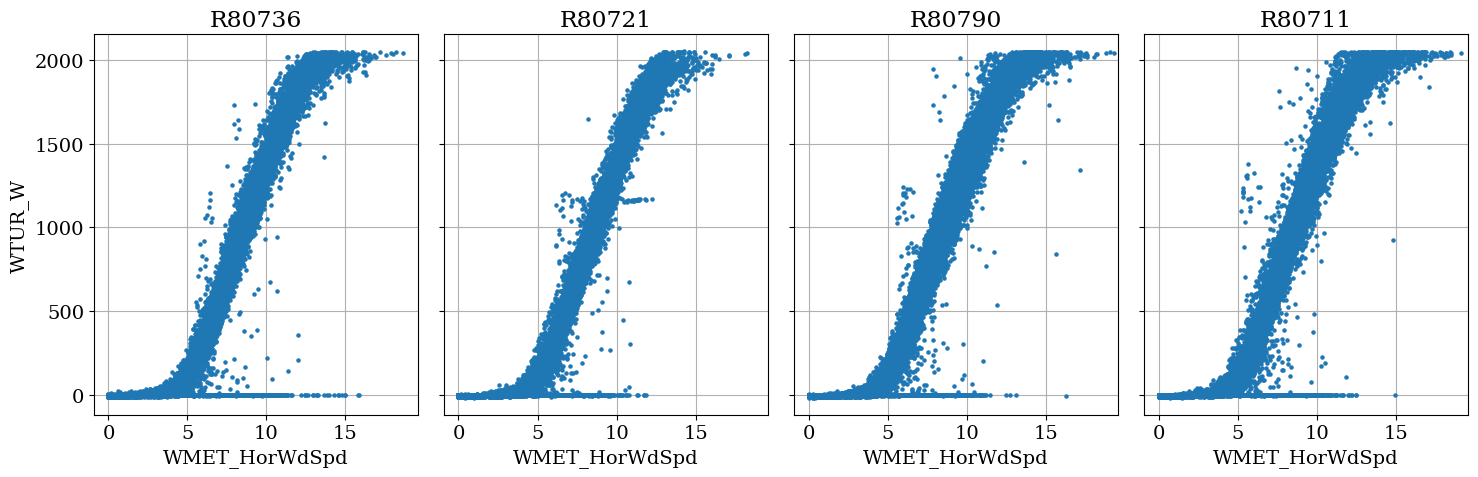

In [6]:
plot.plot_by_id(
    df=project.scada,
    id_col="asset_id",
    x_axis="WMET_HorWdSpd",
    y_axis="WTUR_W",
)

In [7]:
# Get the first turbine's data
turbine_id = project.turbine_ids[0]
print(turbine_id)
turbine_df = project.scada.loc[project.scada.index.get_level_values("asset_id") == turbine_id]

# Remove nans
ix_nan = turbine_df.WMET_HorWdSpd.isna() | turbine_df.WTUR_W.isna()
windspeed = turbine_df.loc[~ix_nan, "WMET_HorWdSpd"].copy()
power_kw = turbine_df.loc[~ix_nan, "WTUR_W"].copy()

# Filter out of window data
ix_out_of_window = filters.window_range_flag(windspeed, 5., 40, power_kw, 20., 2100.)

# Filter out binned outliers
max_bin = 0.90 * power_kw.max()
ix_bin_outliers = filters.bin_filter(power_kw, windspeed, 100, 1.5, "median", 20., max_bin, "scalar", "all")

# Filter out unresponsive points
ix_frozen = filters.unresponsive_flag(windspeed, 3)

# Combine the filters
ix_remove = ix_out_of_window | ix_bin_outliers | ix_bin_outliers | ix_frozen

R80711


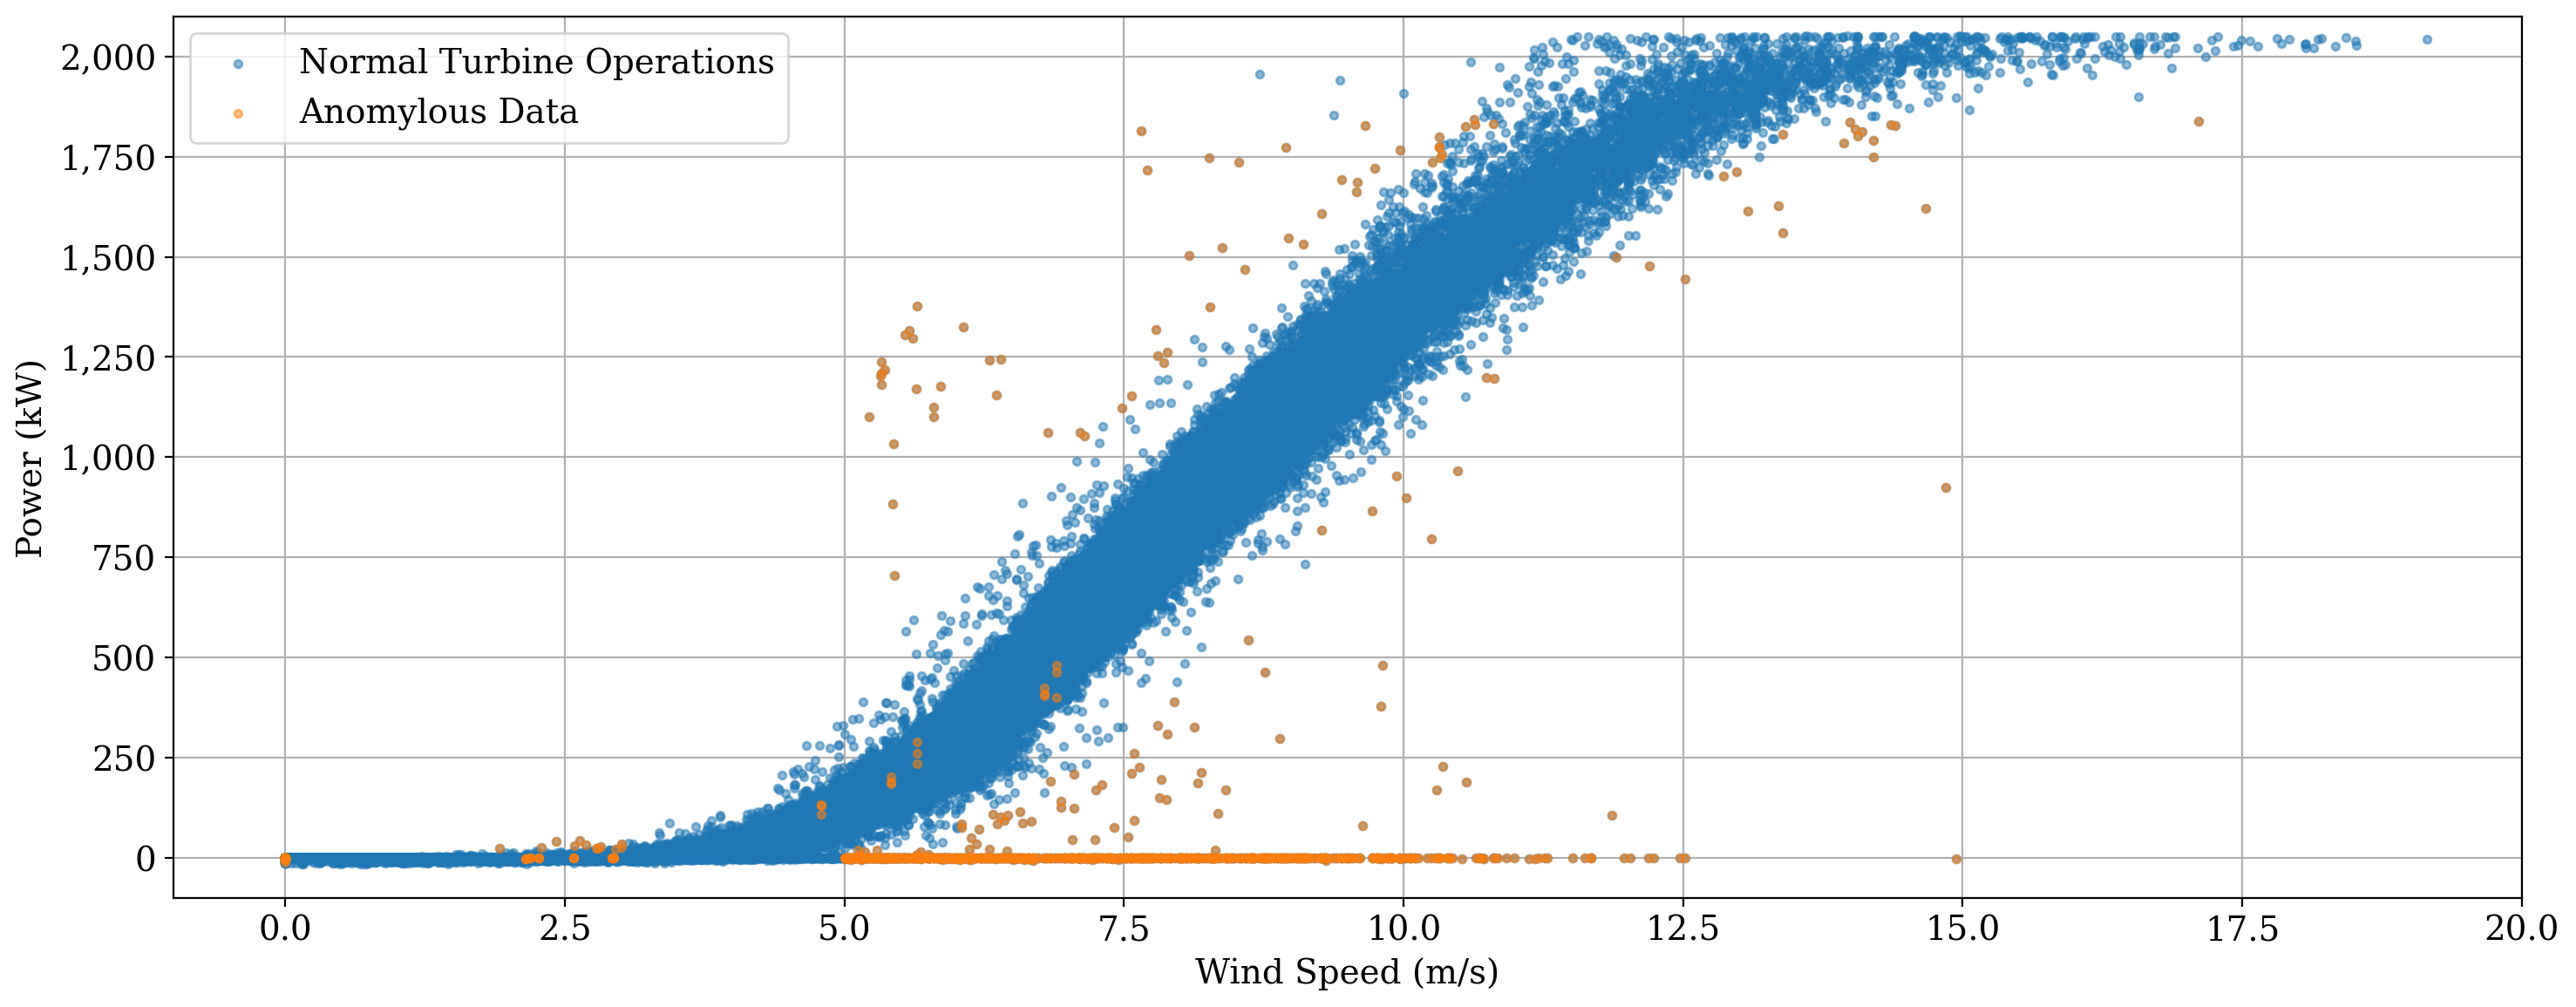

In [8]:
plot.plot_power_curve(
    windspeed,
    power_kw,
    flag=ix_remove,
    flag_labels=("Anomylous Data", "Normal Turbine Operations"),
    xlim=(-1, 20),  # optional input for refining plots
    ylim=(-100, 2100),  # optional input for refining plots
    legend=True,  # optional flag for adding a legend
    scatter_kwargs=dict(alpha=0.5, s=10)  # optional input for refining plots
)

In [9]:
windspeed_final = windspeed.loc[~ix_remove]
power_kw_final = power_kw.loc[~ix_remove]

iec_curve = power_curve.IEC(windspeed_final, power_kw_final)
l5p_curve = power_curve.logistic_5_parametric(windspeed_final, power_kw_final)
spline_curve = power_curve.gam(windspeed_final, power_kw_final, n_splines=20)

  return d + (a - d) / (1 + (x / c) ** b) ** g



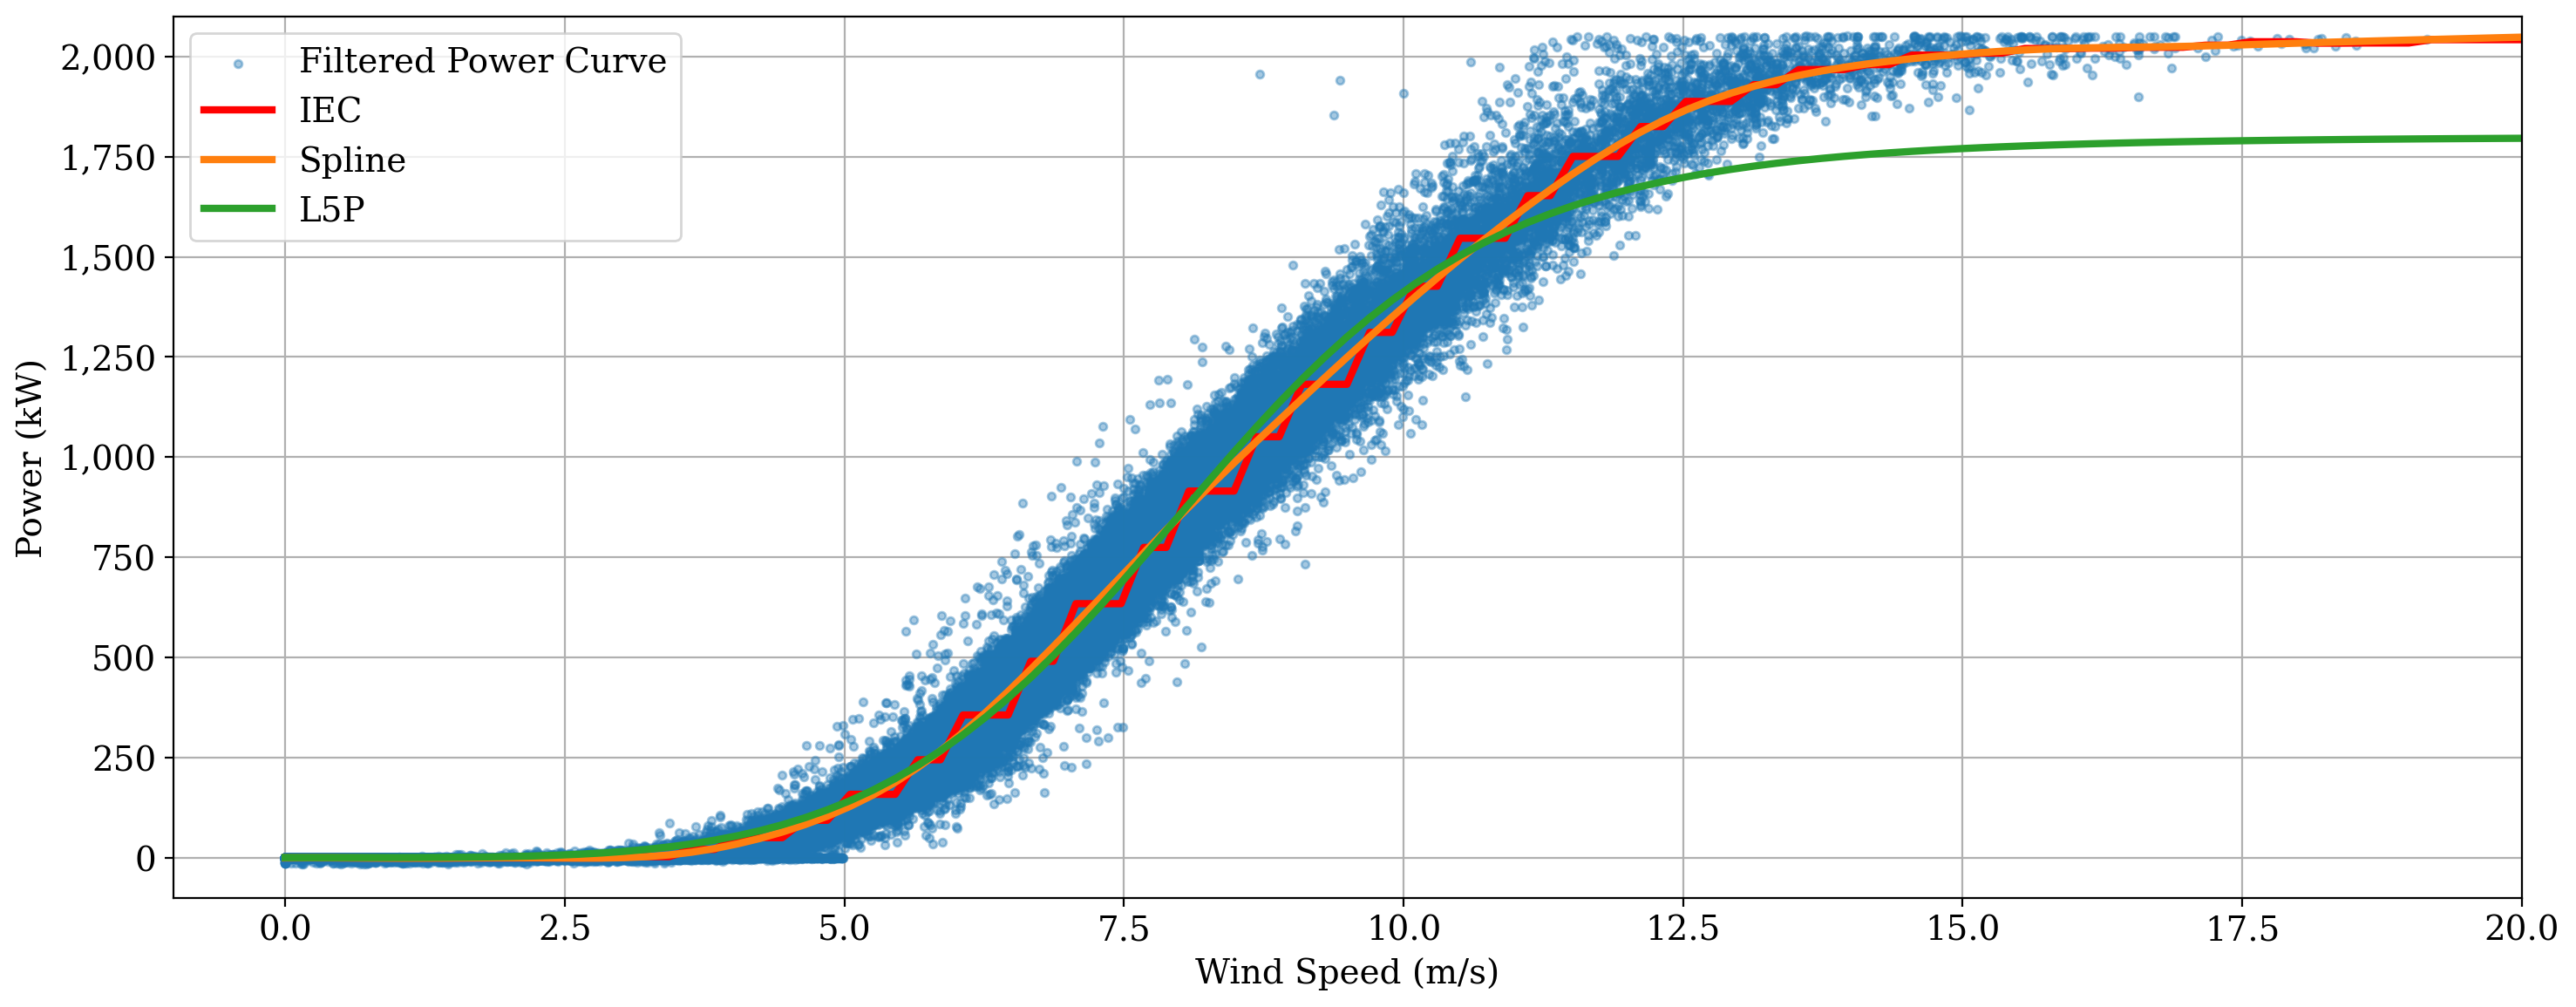

In [10]:
fig, ax = plot.plot_power_curve(
    windspeed_final,
    power_kw_final,
    flag=np.zeros(windspeed_final.shape, dtype=bool),
    flag_labels=("", "Filtered Power Curve"),
    xlim=(-1, 20),  # optional input for refining plots
    ylim=(-100, 2100),  # optional input for refining plots
    legend=False,  # optional flag for adding a legend
    scatter_kwargs=dict(alpha=0.4, s=10),  # optional input for refining plots
    return_fig=True,
)

x = np.linspace(0, 20, 100)
ax.plot(x, iec_curve(x), color="red", label = "IEC", linewidth = 3)
ax.plot(x, spline_curve(x), color="C1", label = "Spline", linewidth = 3)
ax.plot(x, l5p_curve(x), color="C2", label = "L5P", linewidth = 3)

ax.legend()

fig.tight_layout()
plt.show()

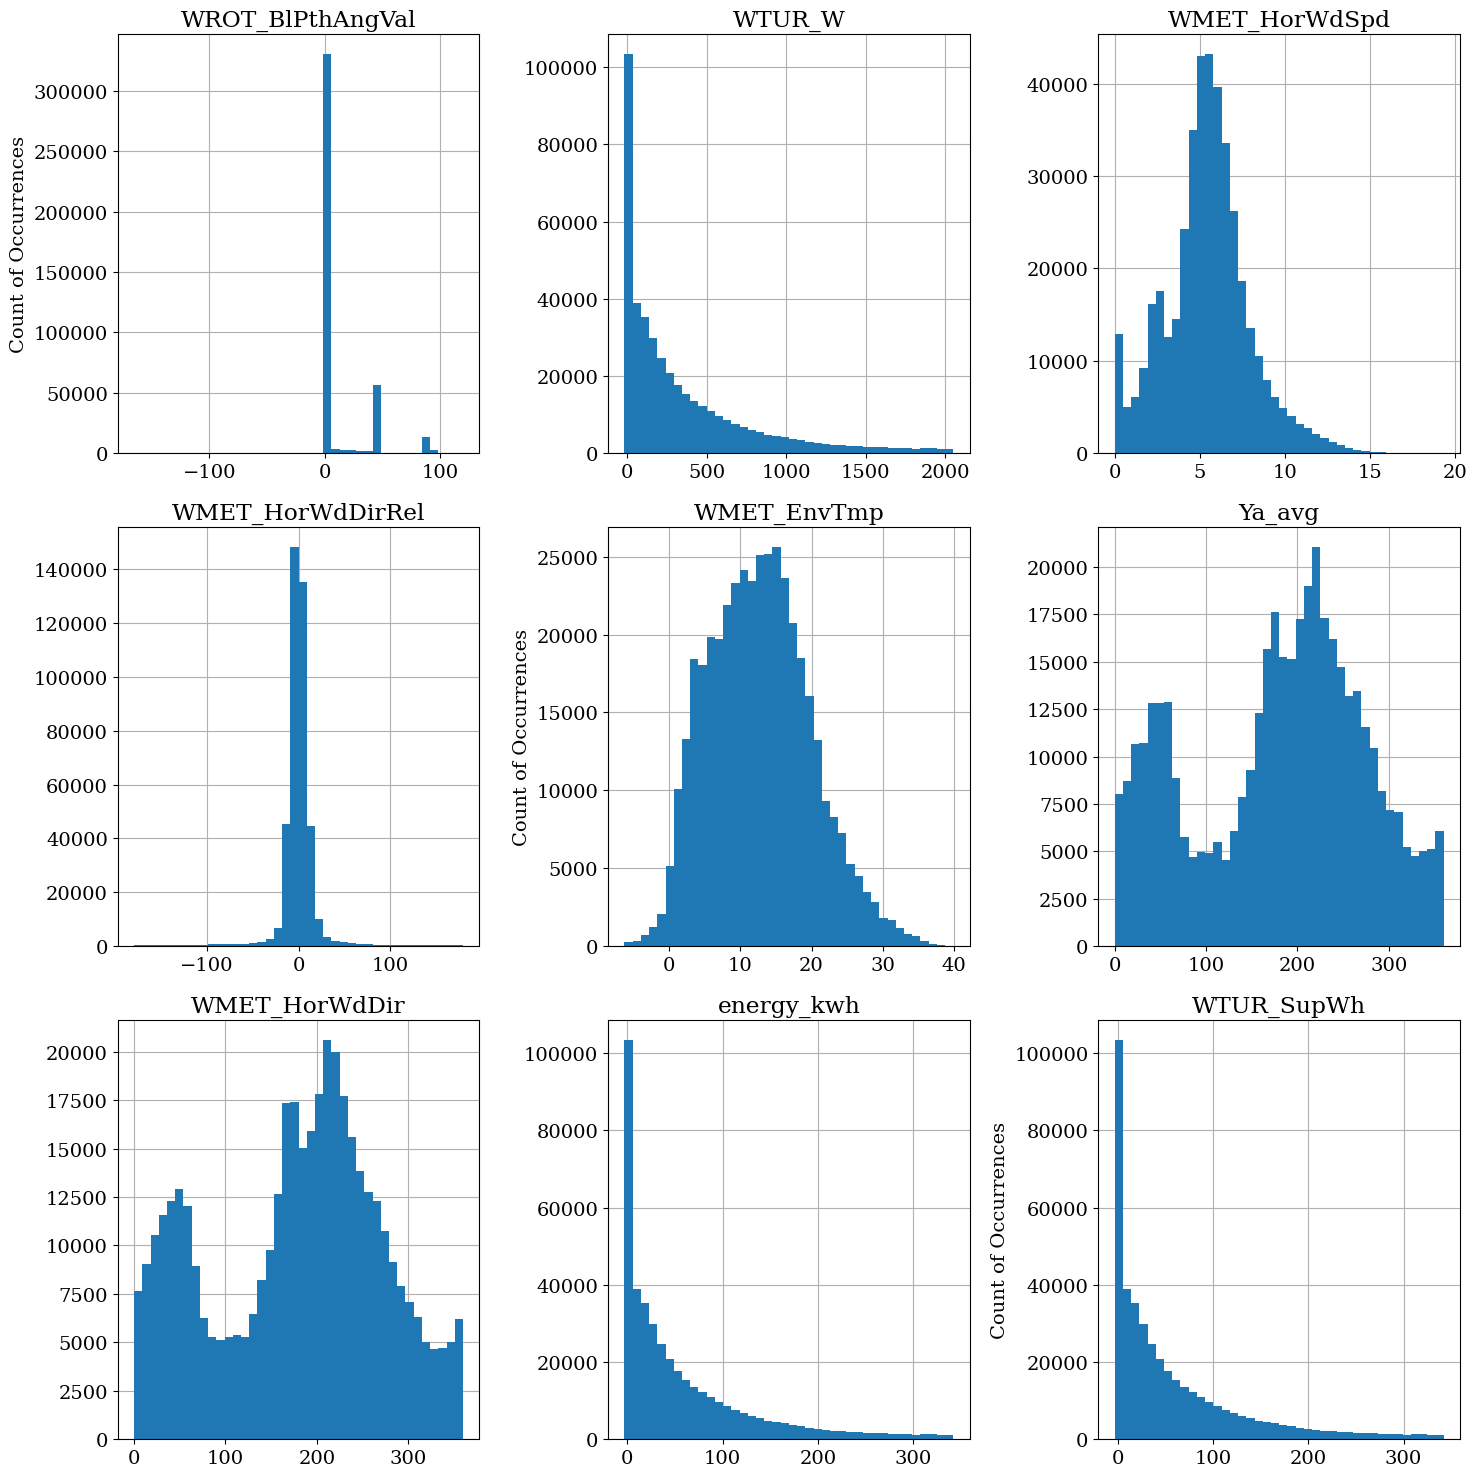

In [11]:
plot.column_histograms(project.scada)

In [12]:
ta = TurbineLongTermGrossEnergy(
    project,
    UQ=True,  # enable uncertainty quantification
    num_sim=20,  # number of Monte Carlo simulations to perform
    wind_bin_threshold=(1, 3),  # Data outside of a range of +-1 to +-3 standard deviations from the median for each power bin are discarded
    max_power_filter=(0.8, 0.9),  # The bin filter will be applied up to fractions of turbine capacity from 80% to 90%
    uncertainty_scada=0.005,  # Assumed uncertainty of SCADA power data (0.5%)
    correction_threshold=(0.85, 0.95),
)
ta.run()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:32<00:00,  1.61s/it]


In [13]:
# Mean long-term annual TIE for whole plant
print(f"Mean long-term turbine ideal energy is {np.mean(ta.plant_gross / 1e6):,.1f} GWh/year")

# Uncertainty in long-term annual TIE for whole plant
print(f"Uncertainty in long-term turbine ideal energy is {np.std(ta.plant_gross / 1e6):,.1f} GWh/year, or {np.std(ta.plant_gross) / np.mean(ta.plant_gross):.1%} percent")

Mean long-term turbine ideal energy is 13.8 GWh/year
Uncertainty in long-term turbine ideal energy is 0.9 GWh/year, or 6.6% percent


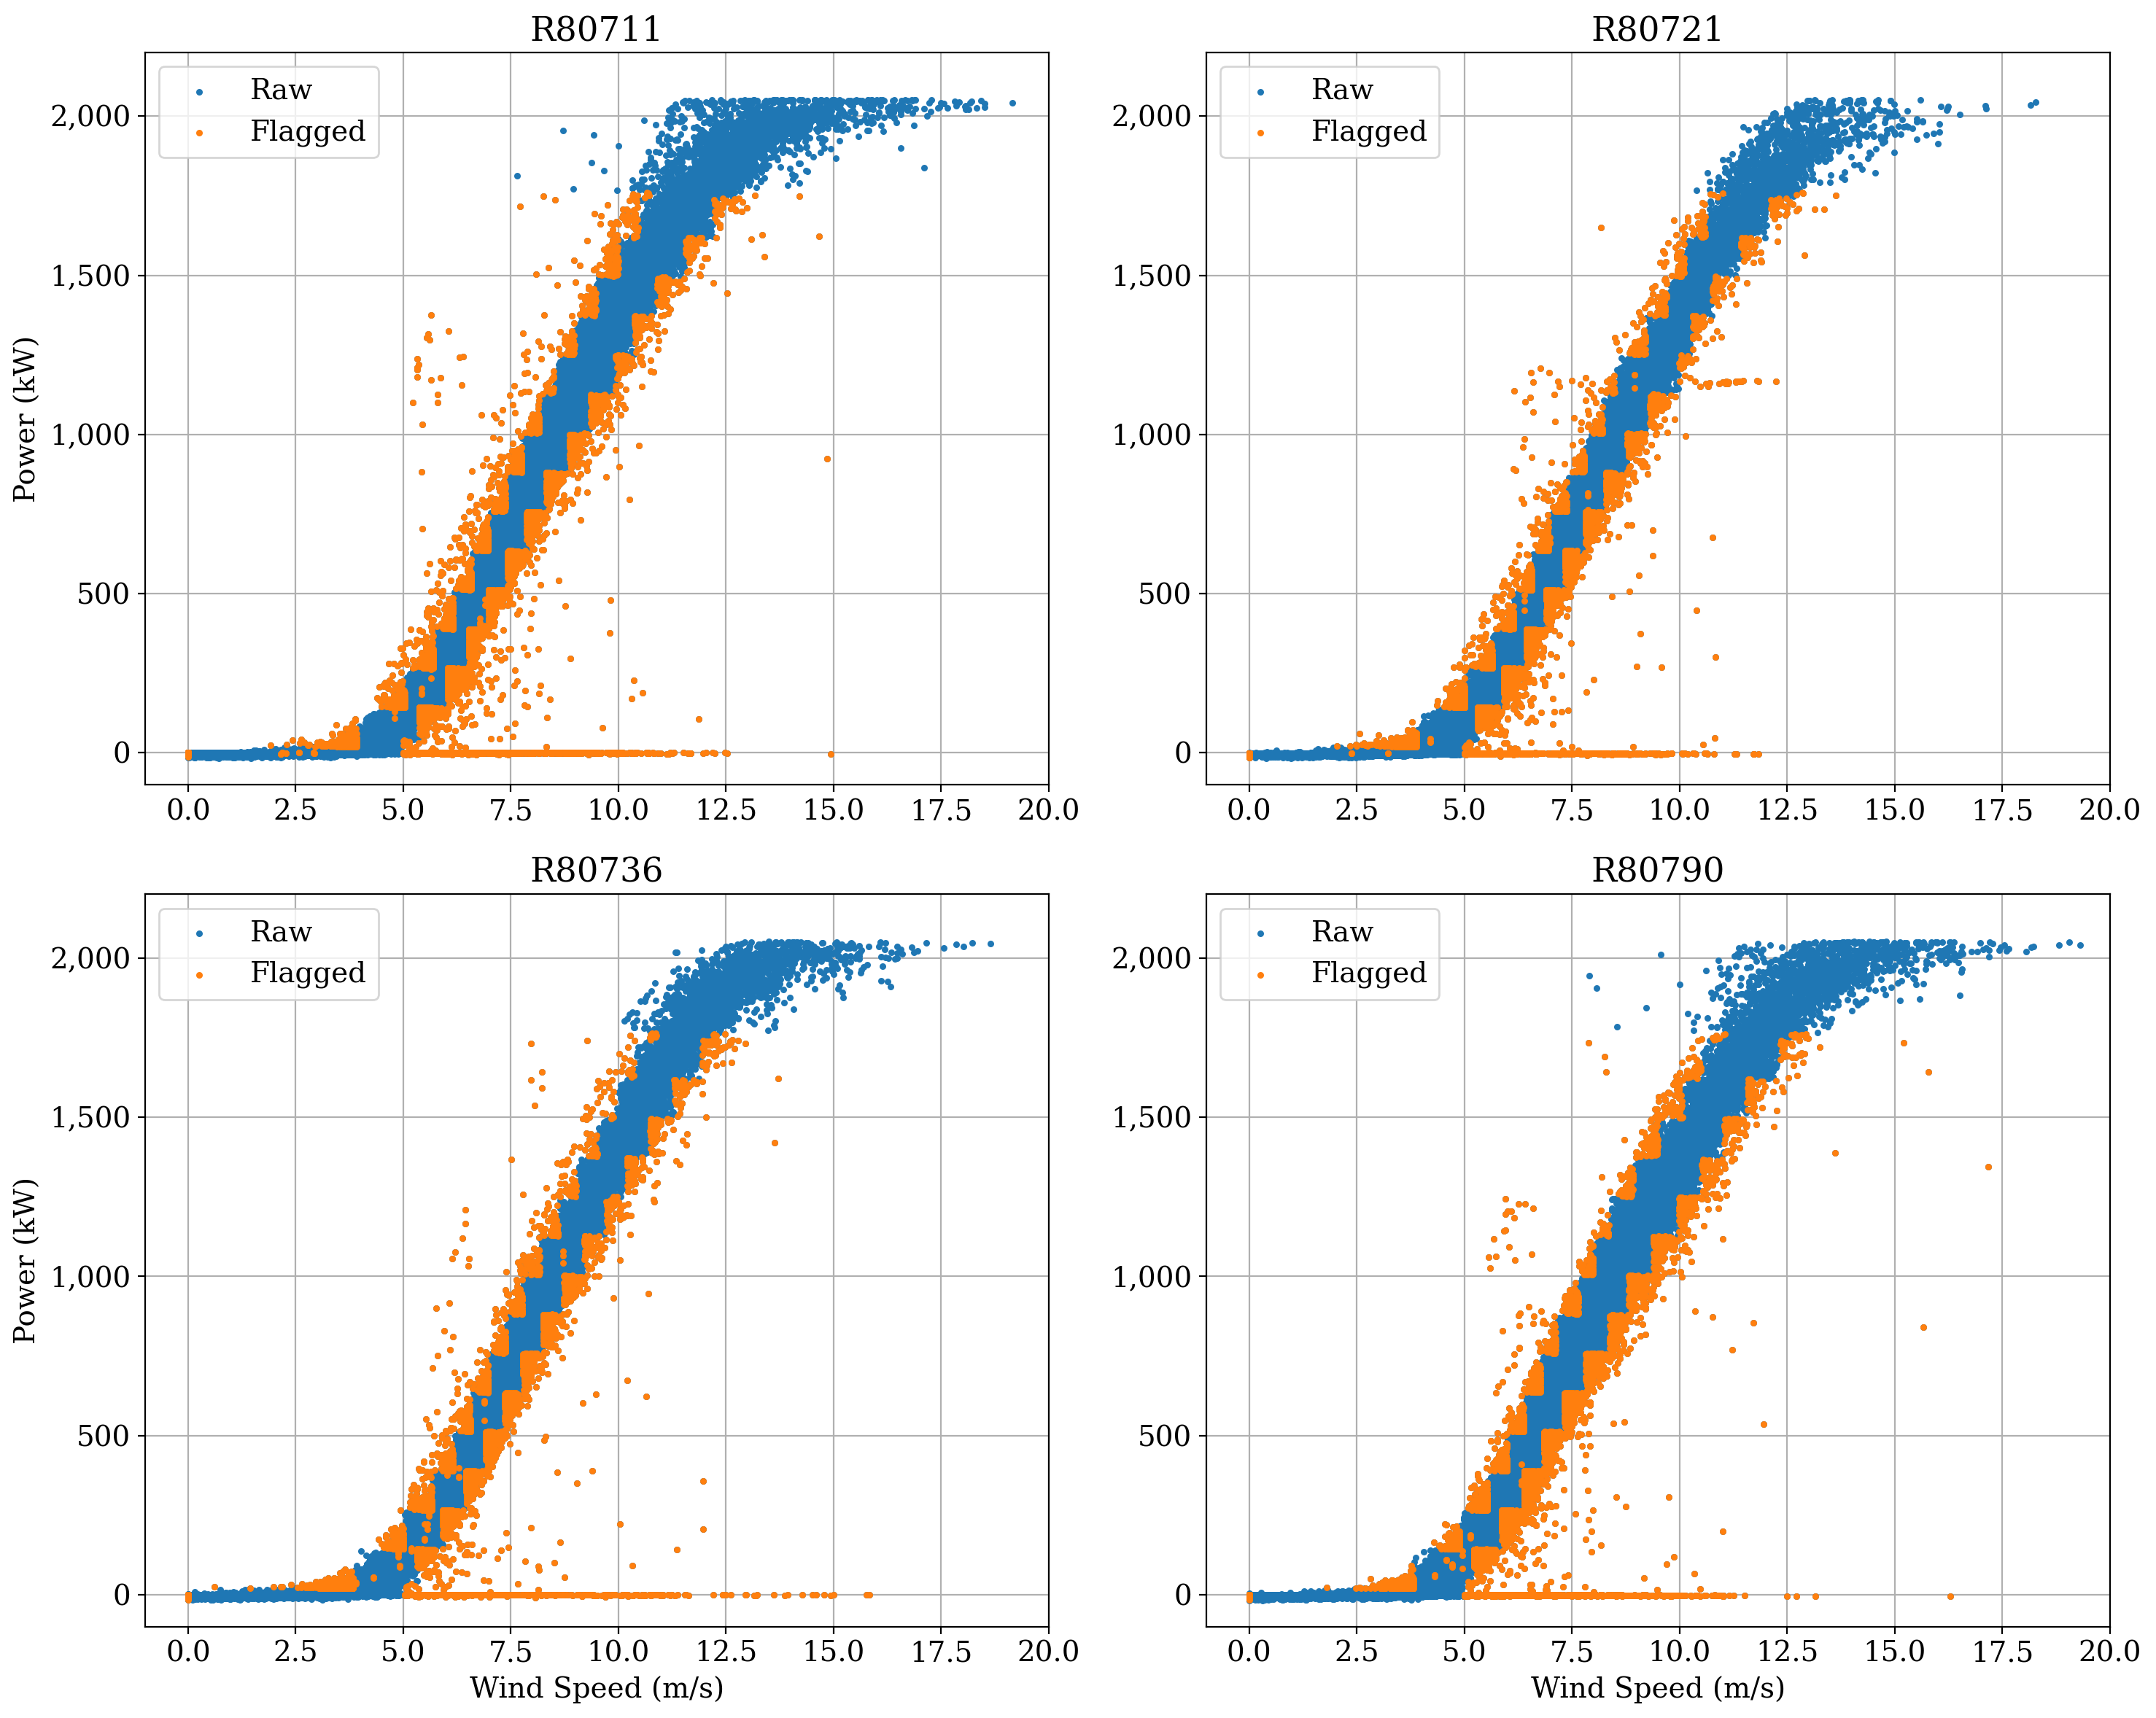

In [14]:
ta.plot_filtered_power_curves(
    flag_labels=("Flagged", "Raw"),
    legend=True,
    max_cols=2,
    xlim=(-1, 20),
    ylim=(-100, 2200),
    figure_kwargs=dict(figsize=(15, 12)),
    plot_kwargs=dict(s=5),
)


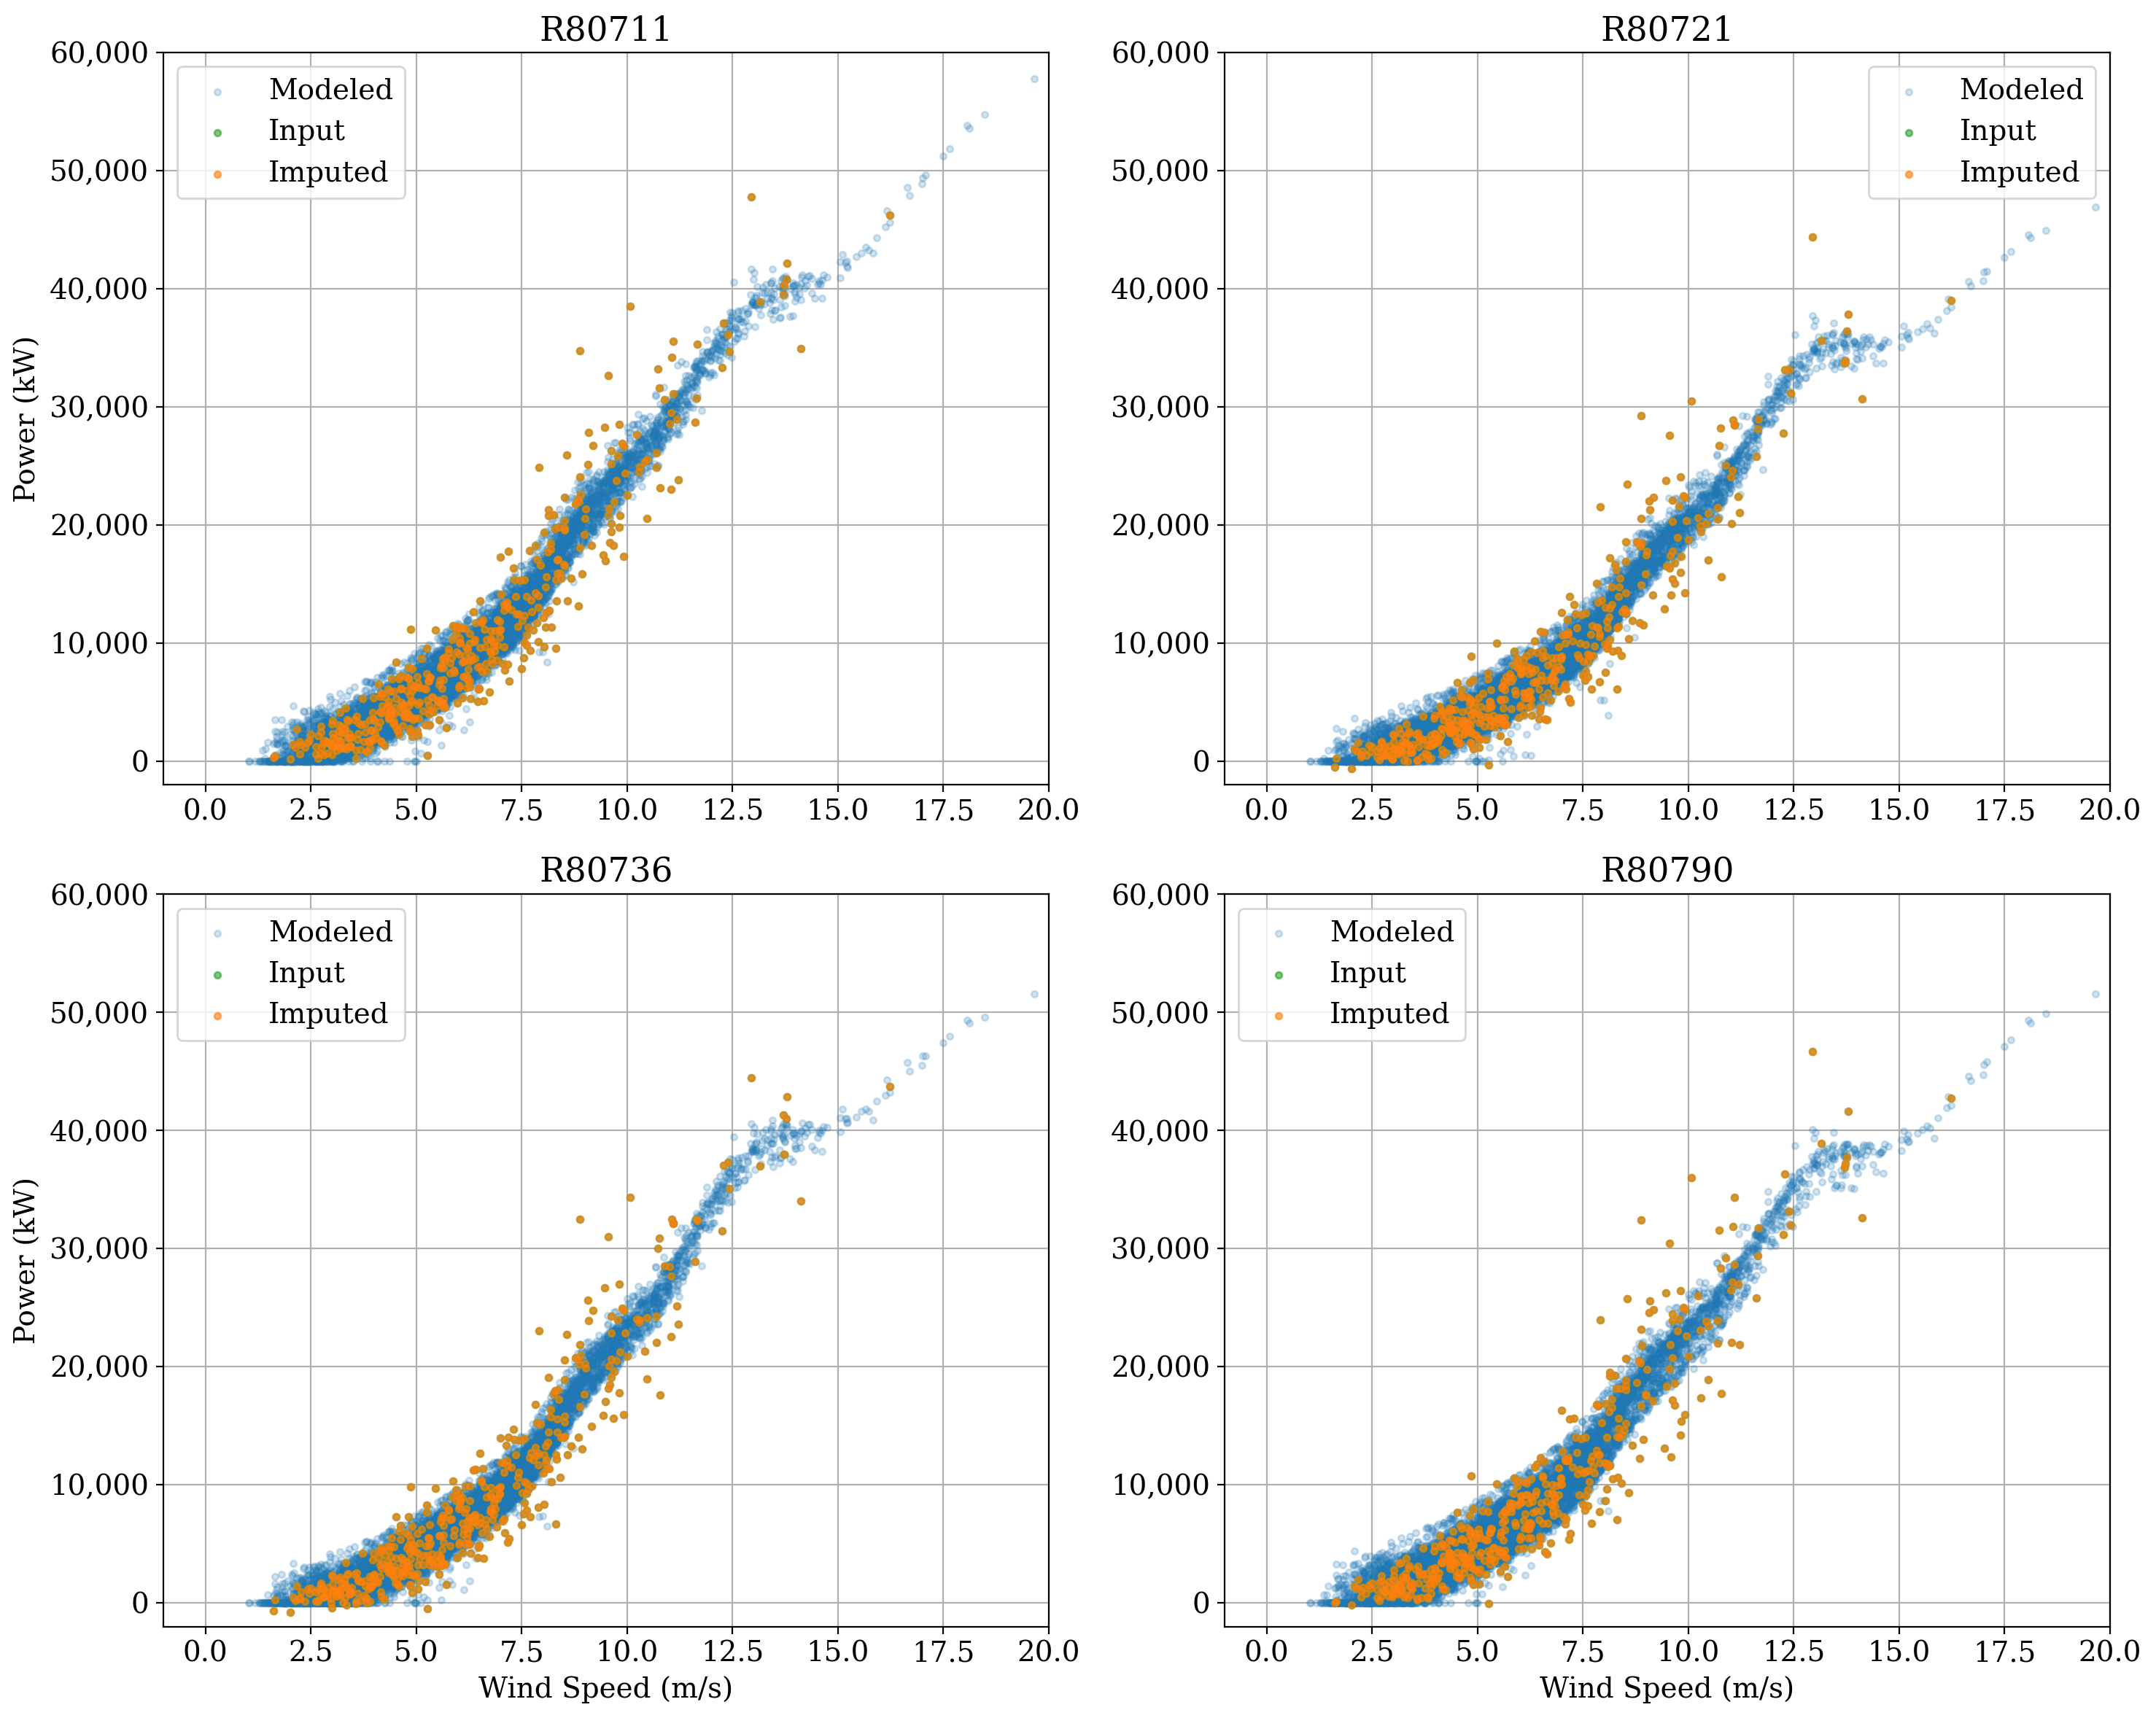

In [15]:
ta.plot_daily_fitting_result(
    legend=True,
    max_cols=2,
    xlim=(-1, 20),
    ylim=(-2000, 60000),
    plot_kwargs={"s": 10},
    figure_kwargs={"figsize": (15, 12)},
)

In [16]:
aep_gam = project.MonteCarloAEP(
    reanalysis_products=["merra2", "era5"],
    time_resolution="h",
    reg_temperature=False,
    reg_wind_direction=False,
    reg_model="gam",
)

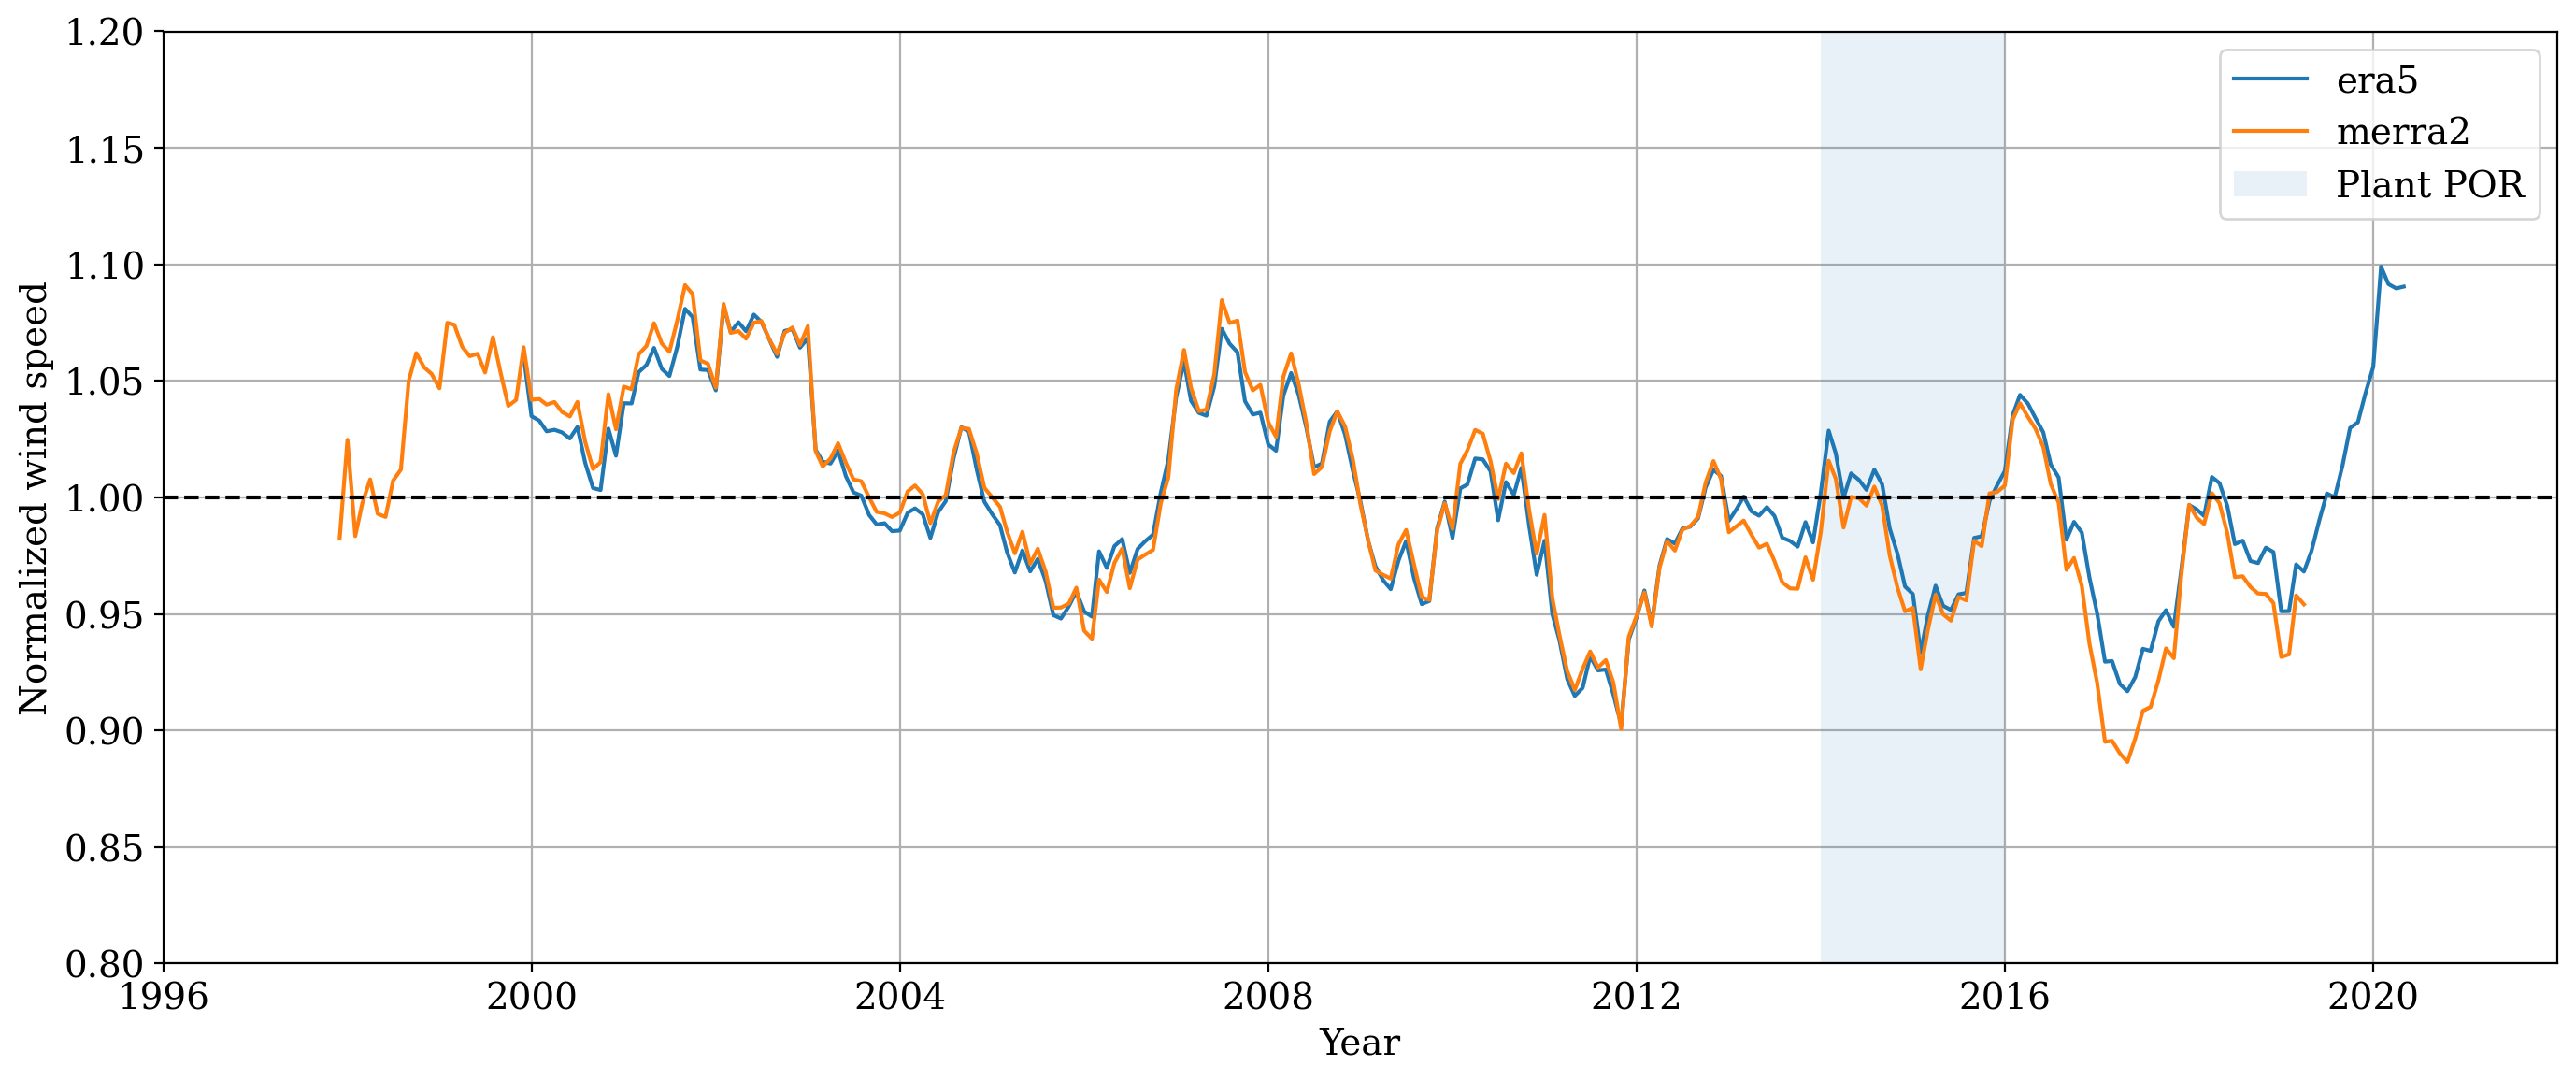

In [18]:
aep_gam.plot_normalized_monthly_reanalysis_windspeed(
    return_fig=False,
    xlim=(datetime(1996, 1, 1), datetime(2021, 12, 31)),
    ylim=(0.8, 1.2),
)

In [19]:
aep_gam.run(num_sim=100)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:42<00:00,  2.35it/s]


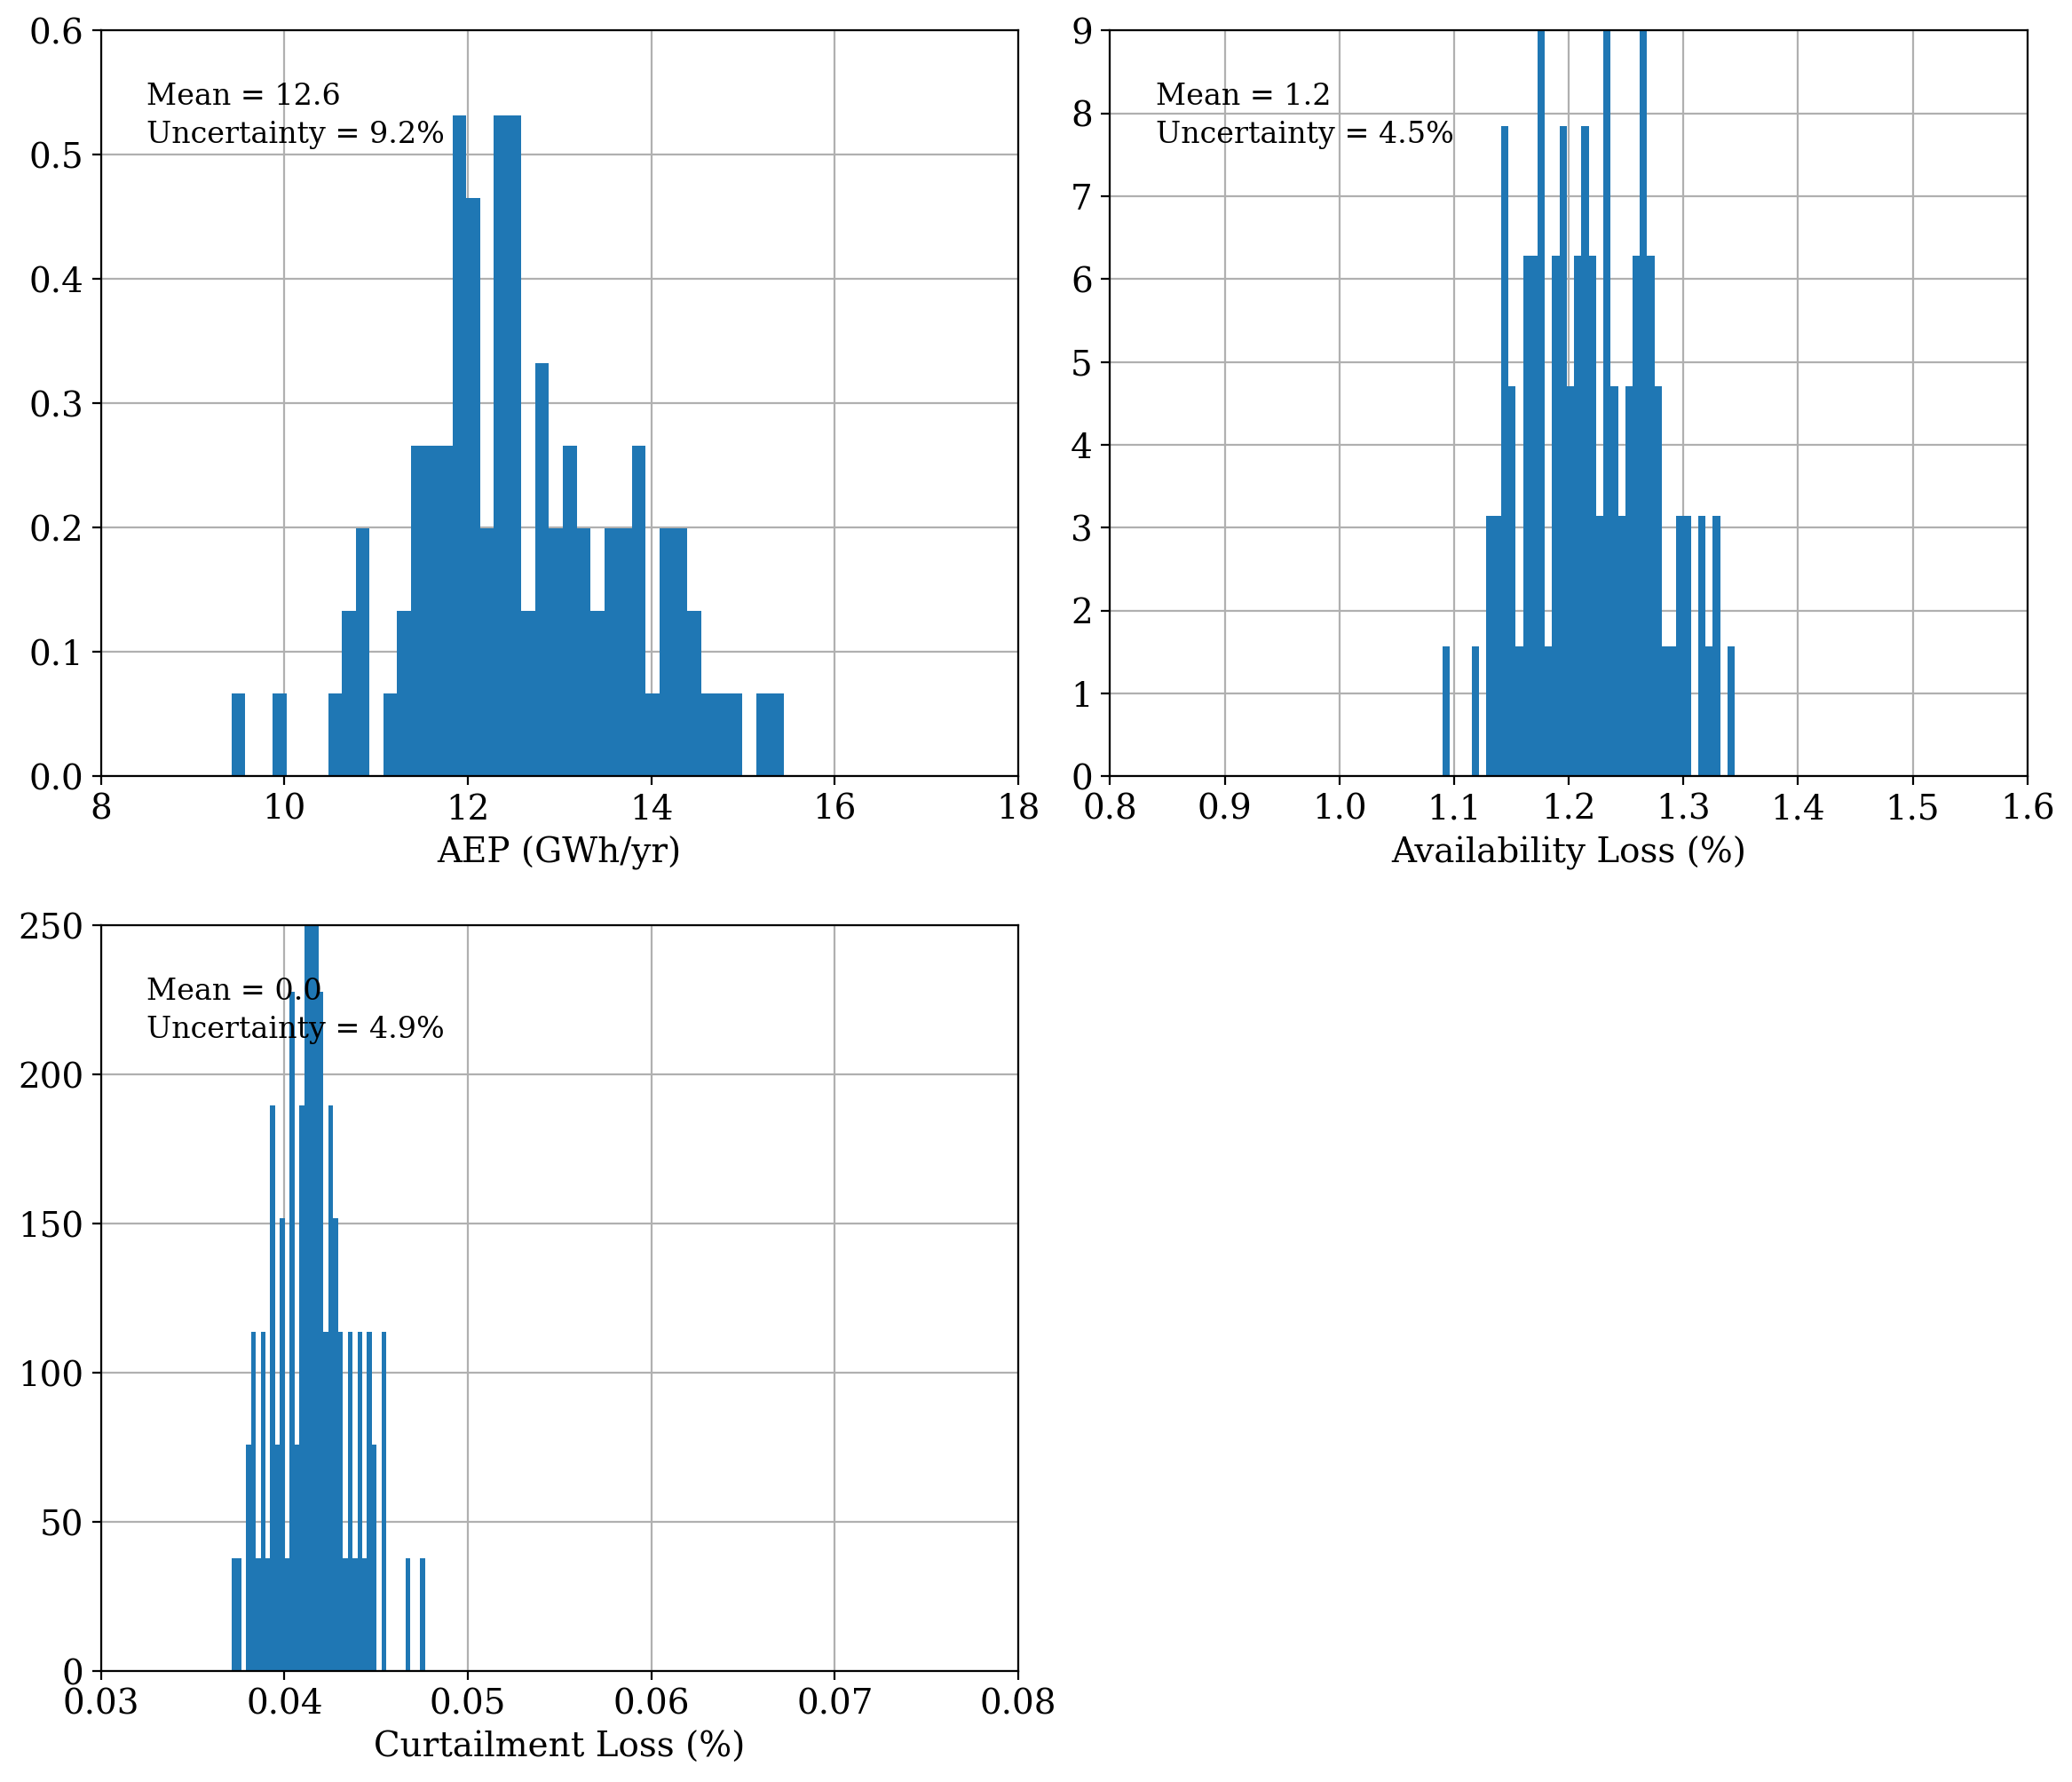

In [20]:
aep_gam.plot_result_aep_distributions(
    xlim_aep=(8, 18),
    xlim_availability=(0.8, 1.6),
    xlim_curtail=(0.03, 0.08),
    ylim_aep=(0, 0.6),
    ylim_availability=(0, 9),
    ylim_curtail=(0, 250),
)

In [21]:
aep_gam.run(num_sim=1000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [05:10<00:00,  3.22it/s]


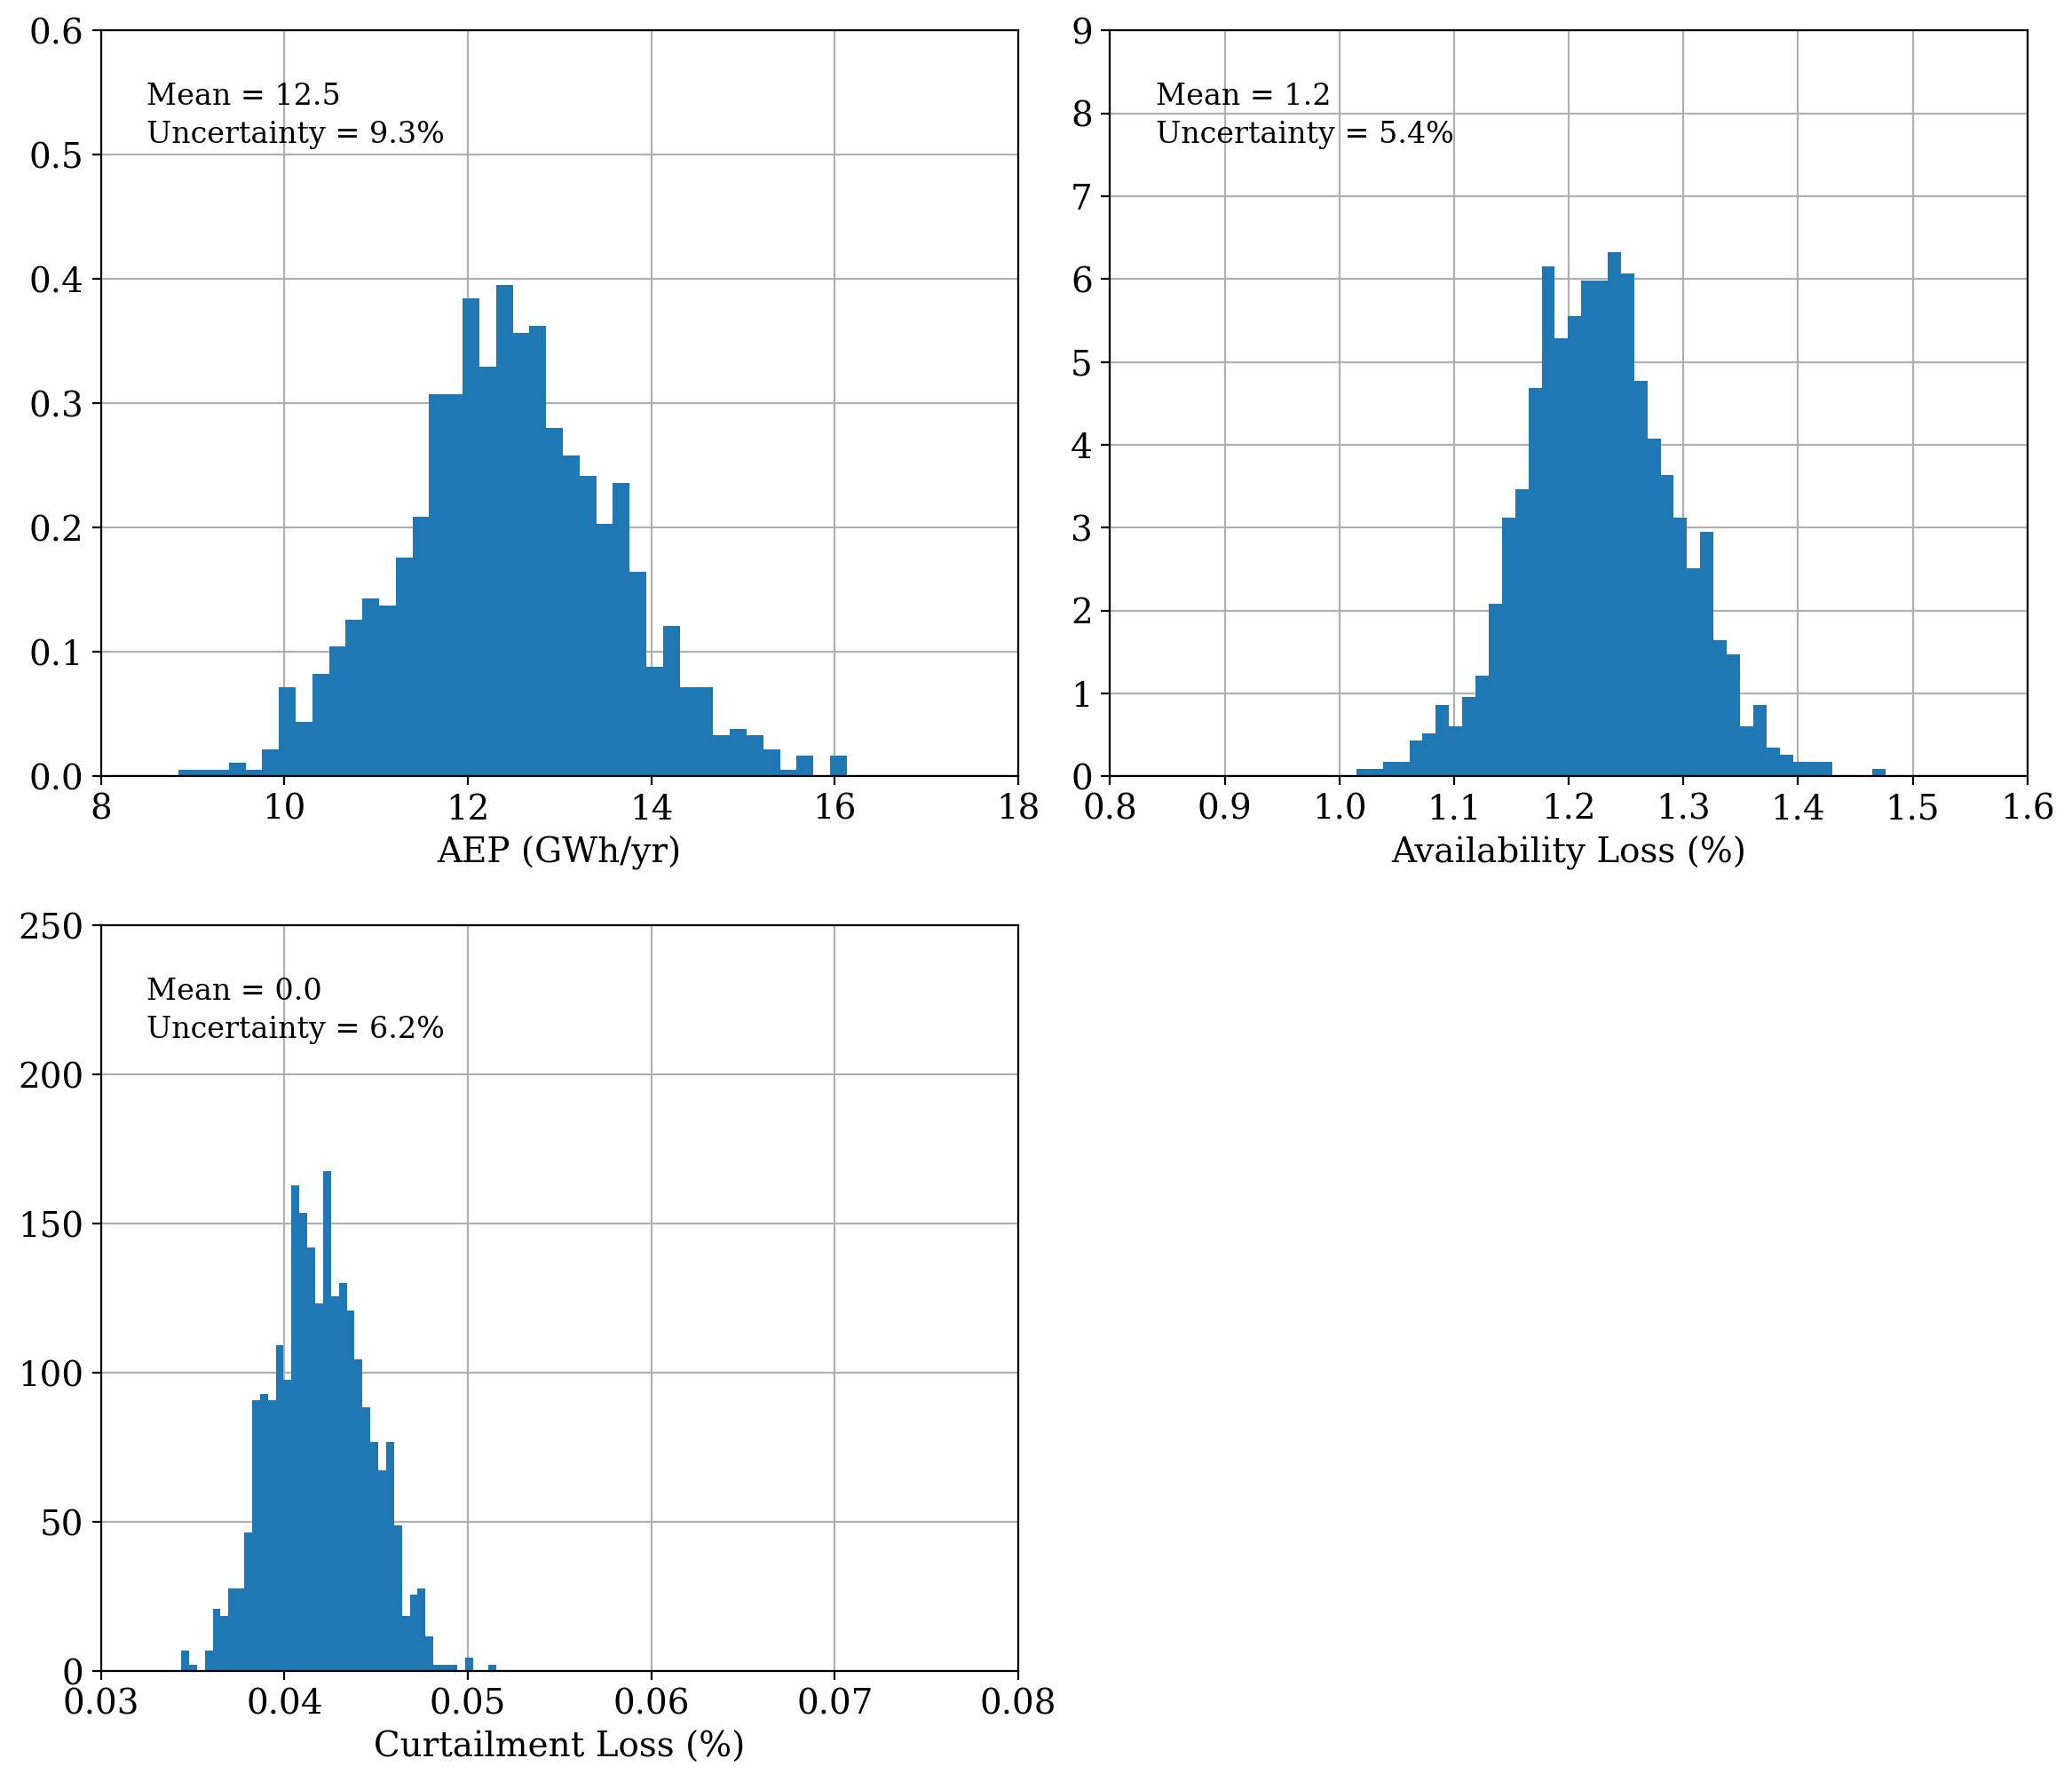

In [22]:
aep_gam.plot_result_aep_distributions(
    xlim_aep=(8, 18),
    xlim_availability=(0.8, 1.6),
    xlim_curtail=(0.03, 0.08),
    ylim_aep=(0, 0.6),
    ylim_availability=(0, 9),
    ylim_curtail=(0, 250),
)

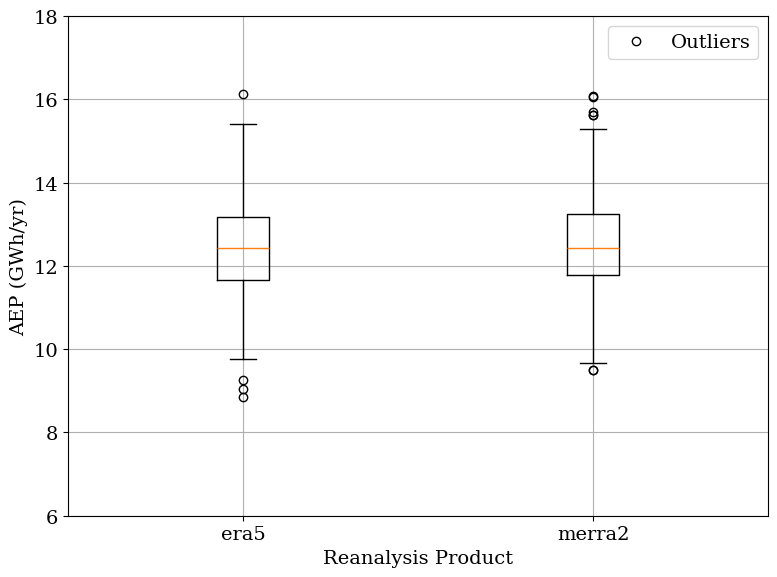

In [23]:
aep_gam.plot_aep_boxplot(x=aep_gam.mc_inputs['reanalysis_product'], xlabel="Reanalysis Product", ylim=(6, 18))

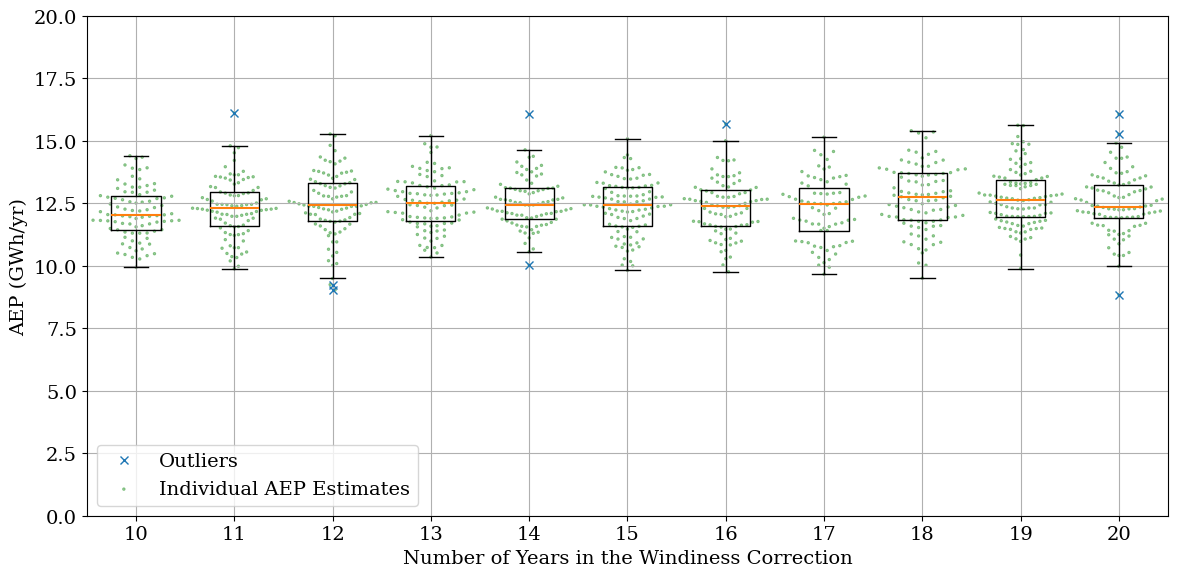

In [24]:
aep_gam.plot_aep_boxplot(
    x=aep_gam.mc_inputs.num_years_windiness,
    xlabel="Number of Years in the Windiness Correction",
    ylim=(0, 20),
    figure_kwargs=dict(figsize=(12, 6)),
    plot_kwargs_box={
        "flierprops": dict(marker="x", markeredgecolor="tab:blue"),
        "medianprops": dict(linewidth=1.5)
    },
    return_fig=False,
    with_points=True,
    points_label="Individual AEP Estimates",
    plot_kwargs_points=dict(alpha=0.5, s=2),
    legend_kwargs=dict(loc="lower left"),
)